In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , QuantileTransformer , RobustScaler

In [238]:
df=pd.read_csv("/content/drive/MyDrive/data_banknote_authentication.csv")
df.head()

,Variance_Wavelet,Skewness_Wavelet,Curtosis_Wavelet,Image_Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [239]:
df.describe()

,Variance_Wavelet,Skewness_Wavelet,Curtosis_Wavelet,Image_Entropy,Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [240]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Variance_Wavelet  1372 non-null   float64
 1   Skewness_Wavelet  1372 non-null   float64
 2   Curtosis_Wavelet  1372 non-null   float64
 3   Image_Entropy     1372 non-null   float64
 4   Class             1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [241]:
df.isnull().sum()

,0
Variance_Wavelet,0
Skewness_Wavelet,0
Curtosis_Wavelet,0
Image_Entropy,0
Class,0


In [242]:
df.shape

(1372, 5)

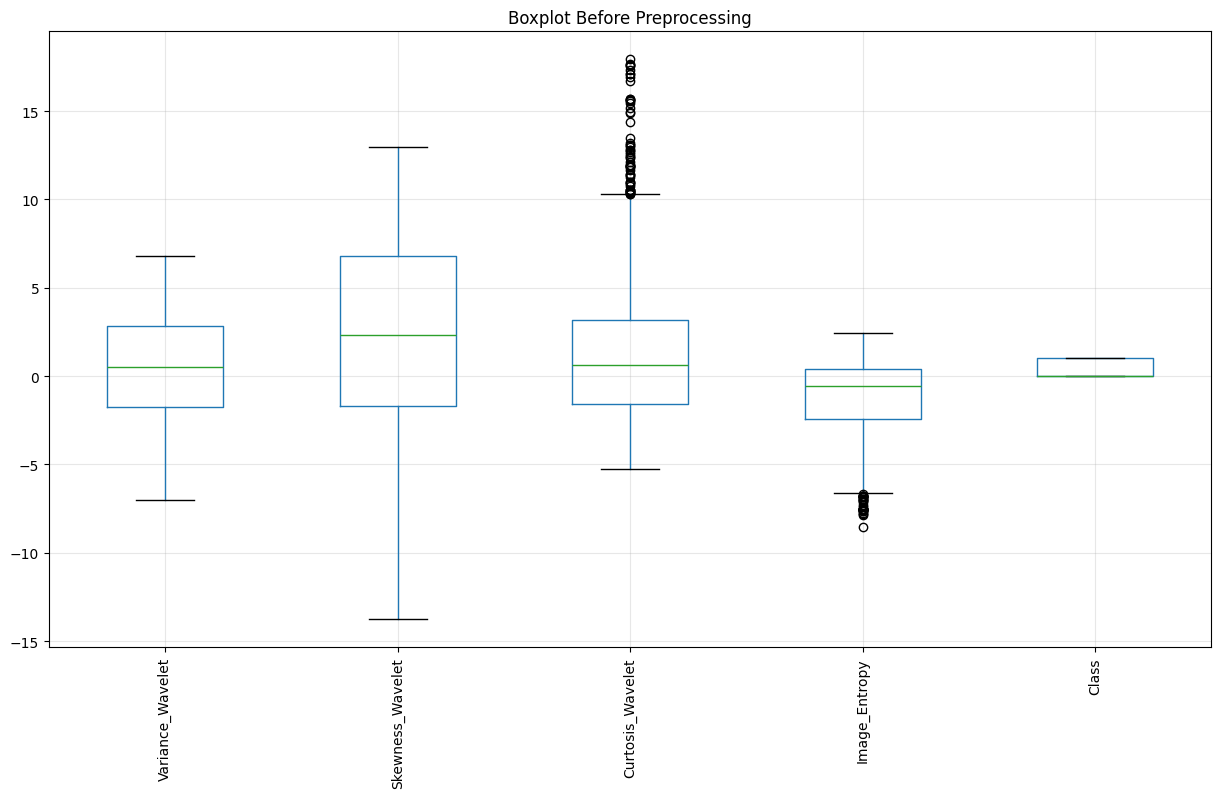

In [243]:
plt.figure(figsize=(15,8))

df.boxplot(rot=90)

plt.title("Boxplot Before Preprocessing")

plt.grid(alpha=0.3)
plt.show()

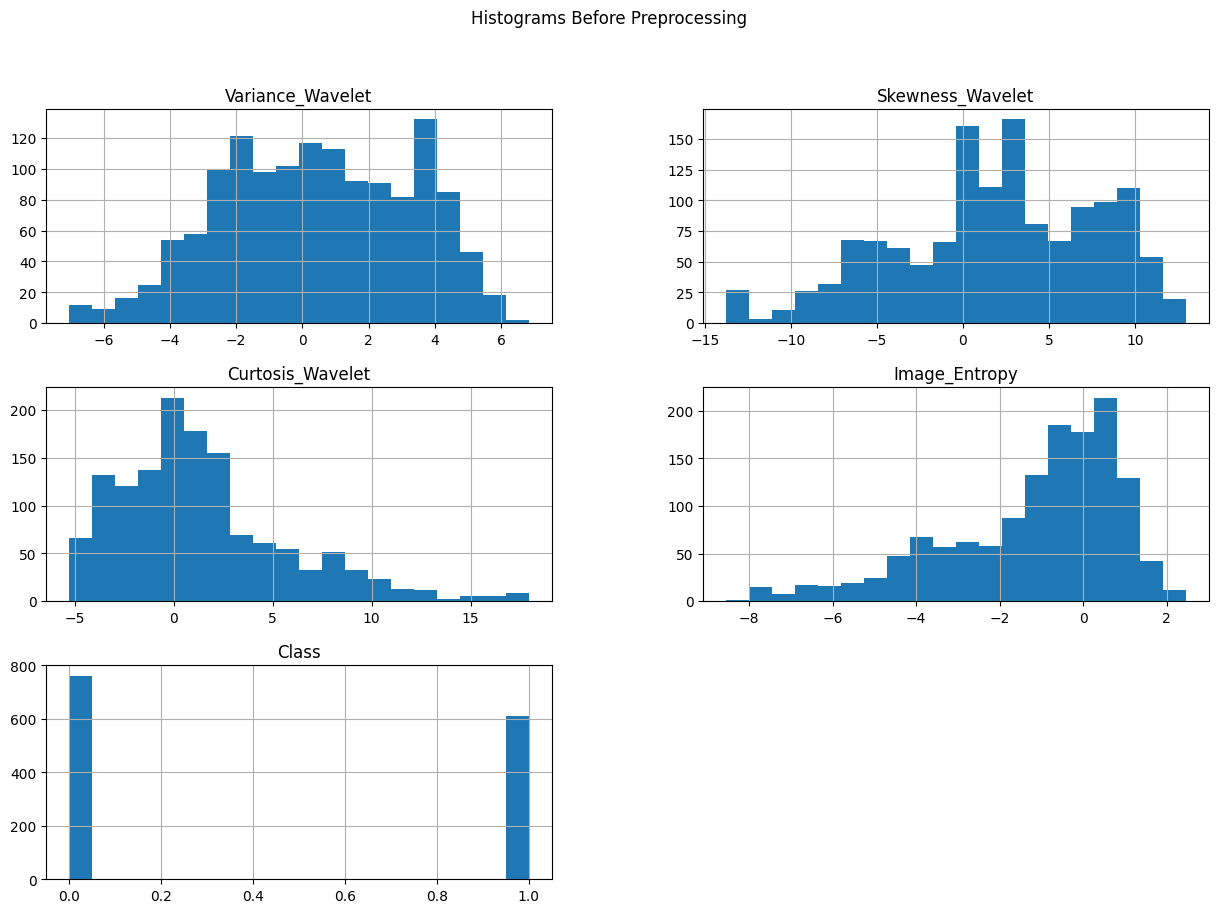

In [244]:
df.hist(figsize=(15,10), bins=20)

plt.suptitle("Histograms Before Preprocessing")

plt.show()

In [246]:
cols =['Curtosis_Wavelet' , 'Image_Entropy']

for col in cols :
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)

  IQR = Q3 - Q1

  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR

  df[col] = np.clip(df[col], lower, upper)

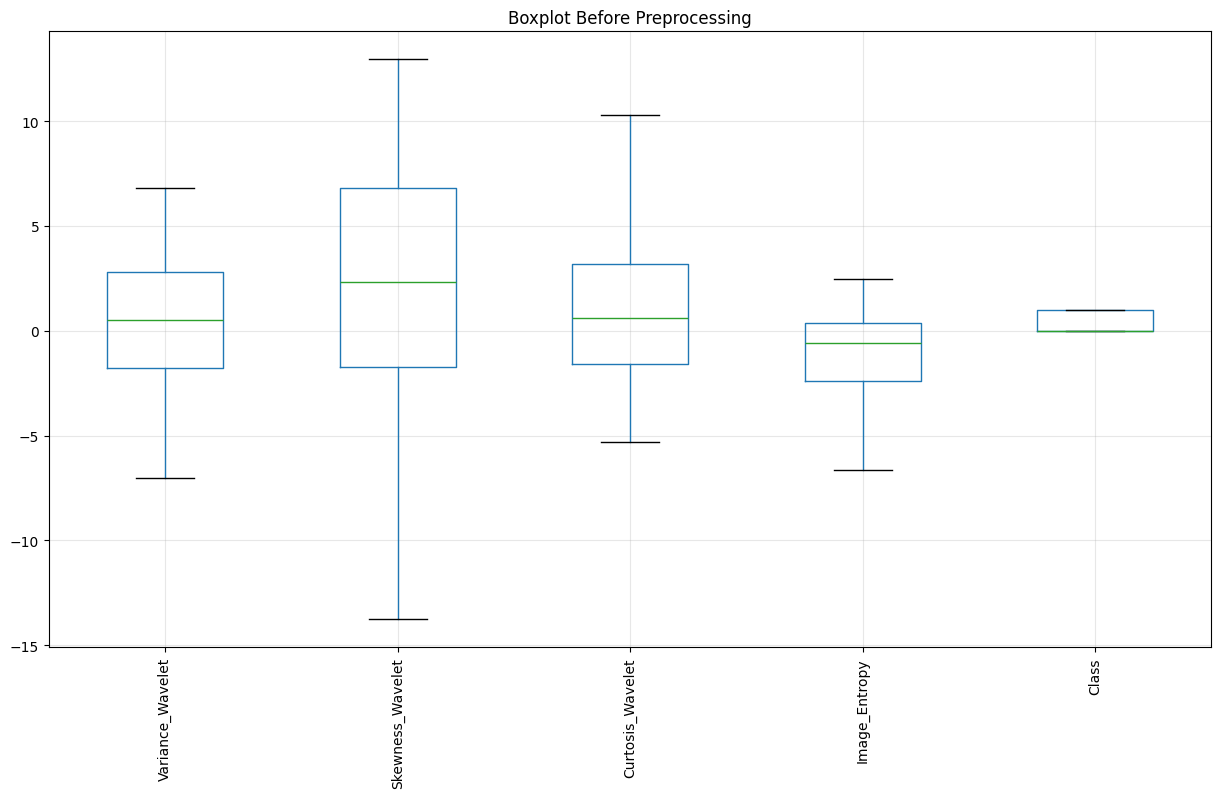

In [247]:
plt.figure(figsize=(15,8))

df.boxplot(rot=90)

plt.title("Boxplot Before Preprocessing")

plt.grid(alpha=0.3)
plt.show()

In [249]:
X = df.drop('Class' , axis=1)
y = df['Class']

In [250]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test= train_test_split(X , y , random_state=42 , test_size=0.2)

In [197]:
!pip install lazypredict

In [251]:
from lazypredict.Supervised import LazyClassifier

clf = LazyClassifier(verbose=0 , ignore_warnings=True , custom_metric=None)
models , predictions = clf.fit(X_train , X_test , y_train , y_test)
print(models)

                               Accuracy  Balanced Accuracy   ROC AUC  \
Model                                                                  
ExtraTreesClassifier           1.000000           1.000000  1.000000   
LabelPropagation               1.000000           1.000000  1.000000   
KNeighborsClassifier           1.000000           1.000000  1.000000   
LGBMClassifier                 1.000000           1.000000  1.000000   
SVC                            1.000000           1.000000  1.000000   
LabelSpreading                 1.000000           1.000000  1.000000   
AdaBoostClassifier             0.996364           0.996063  0.999681   
XGBClassifier                  0.996364           0.996063  1.000000   
NuSVC                          0.992727           0.993243  0.999787   
RandomForestClassifier         0.992727           0.992126  0.999894   
SGDClassifier                  0.992727           0.992126  0.999628   
QuadraticDiscriminantAnalysis  0.985455           0.986486  0.99

In [254]:
df.corr()['Class'].sort_values(ascending=False)

,Class
Class,1.000000
Curtosis_Wavelet,0.134242
Image_Entropy,-0.025239
Skewness_Wavelet,-0.444688
Variance_Wavelet,-0.724843


In [255]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report , recall_score , precision_score , f1_score

In [256]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [257]:
model = SVC(random_state=42, max_iter=5000)
model.fit(X_train, y_train)

SVC(max_iter=5000, random_state=42)

In [258]:
y_pred = model.predict(X_test)

In [259]:
print("accuracy:", accuracy_score(y_test, y_pred))
print("precision:", precision_score(y_test, y_pred))
print("recall:", recall_score(y_test, y_pred))
print("f1:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

accuracy: 1.0
precision: 1.0
recall: 1.0
f1: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       148
           1       1.00      1.00      1.00       127

    accuracy                           1.00       275
   macro avg       1.00      1.00      1.00       275
weighted avg       1.00      1.00      1.00       275



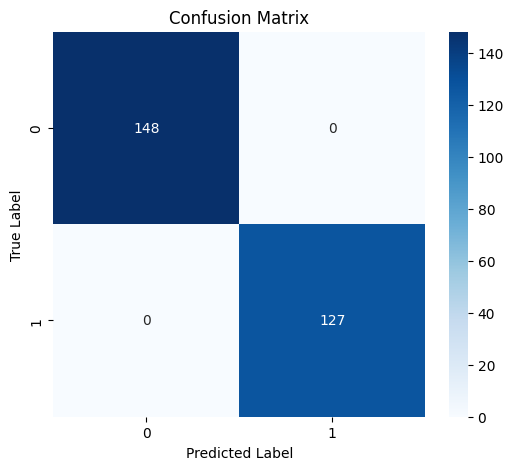

In [260]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()